In [1]:
import torch  # 导入PyTorch库，用于深度学习任务
from PIL import Image  # 导入PIL库中的Image模块，用于图像处理
import os  # 导入os库，用于处理文件和目录路径
from torch.utils.data import Dataset, DataLoader  # 从PyTorch的工具库中导入Dataset类，用于自定义数据集
import numpy as np  # 导入 NumPy 库，用于数值计算
import torchvision.transforms as T  # 导入torchvision.transforms模块，用于图像预处理

In [2]:
class ImageDataset(Dataset):  # 定义一个名为ImageDataset的类，继承自PyTorch的Dataset类
    def __init__(self, main_dir, transform=None):  # 定义类的构造函数，接受两个参数：main_dir（主目录路径）和transform（图像预处理操作，默认为None）
        self.main_dir = main_dir  # 将主目录路径保存为类的属性
        self.transform = transform  # 将图像预处理操作保存为类的属性
        self.all_imgs = os.listdir(main_dir)  # 获取主目录下的所有文件名，并保存为列表

    def __len__(self):  # 定义__len__方法，返回数据集中图像的数量
        return len(self.all_imgs)  # 返回主目录下图像文件的数量

    def __getitem__(self, idx):  # 定义__getitem__方法，根据索引idx获取图像
        img_loc = os.path.join(self.main_dir, self.all_imgs[idx])  # 根据索引idx构建图像的完整路径
        image = Image.open(img_loc).convert("RGB")  # 使用PIL库打开图像并将其转换为RGB格式

        if self.transform is not None:  # 如果定义了图像预处理操作
            tensor_image = self.transform(image)  # 对图像进行预处理，并将其转换为张量
        else:
            # 若无变换，抛出异常提示必须提供预处理
            raise ValueError("transform参数不能为None，需指定预处理方法")

        noise_factor = 0.5
        ## 向输入图像添加随机噪声
        # 生成与 tensor_image 形状相同的随机噪声，乘以噪声因子 noise_factor
        noisy_imgs = tensor_image + noise_factor * torch.randn(*tensor_image.shape)
        # 将图像像素值裁剪到 [0, 1] 范围内，避免超出有效范围
        noisy_imgs = np.clip(noisy_imgs, 0., 1.)

        return noisy_imgs, tensor_image  # 返回预处理后的图像张量（将噪声图片作为输入，将原图作为目标）

In [3]:
# 1. 创建数据集
# 定义转换操作
transform = T.Compose([
    T.Resize((68, 68)),
    T.ToTensor()
])
dataset = ImageDataset(main_dir='../common/dataset/', transform=transform)

print(len(dataset))

24853


In [4]:
print(dataset[0])

(tensor([[[1.0000, 1.0000, 1.0000,  ..., 0.8357, 1.0000, 0.9836],
         [1.0000, 0.6865, 1.0000,  ..., 0.9064, 0.5095, 0.8461],
         [0.3661, 1.0000, 0.3477,  ..., 1.0000, 1.0000, 1.0000],
         ...,
         [1.0000, 1.0000, 0.0310,  ..., 0.0000, 1.0000, 0.7781],
         [0.7932, 1.0000, 1.0000,  ..., 0.4692, 1.0000, 0.9255],
         [0.6973, 0.7201, 1.0000,  ..., 1.0000, 1.0000, 1.0000]],

        [[1.0000, 1.0000, 1.0000,  ..., 1.0000, 0.5677, 0.8476],
         [1.0000, 0.8405, 0.7803,  ..., 1.0000, 1.0000, 1.0000],
         [1.0000, 0.9573, 0.8551,  ..., 1.0000, 1.0000, 0.8534],
         ...,
         [0.3383, 0.2251, 0.8466,  ..., 0.4793, 1.0000, 1.0000],
         [1.0000, 0.8145, 1.0000,  ..., 1.0000, 0.8486, 1.0000],
         [1.0000, 1.0000, 1.0000,  ..., 0.0300, 0.7316, 1.0000]],

        [[1.0000, 1.0000, 0.7188,  ..., 1.0000, 0.6166, 1.0000],
         [0.8987, 1.0000, 0.8421,  ..., 0.0492, 1.0000, 0.8943],
         [0.7474, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1

In [5]:
# 2. 划分训练集和测试集
from torch.utils.data import random_split  # 随机划分数据集

train_dataset, test_dataset = random_split(dataset, [0.75, 0.25])
print(len(train_dataset))
print(len(test_dataset))

18640
6213


In [6]:
# 3. 创建数据加载器
batch_size = 32

train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=True)

In [7]:
for noisy_img, image in train_loader:
    print(noisy_img.size(), image.size())
    break

torch.Size([32, 3, 68, 68]) torch.Size([32, 3, 68, 68])


In [8]:
data_iter = iter(test_loader)
noisy_img, image = next(data_iter)
print(noisy_img.size(), image.size())

torch.Size([32, 3, 68, 68]) torch.Size([32, 3, 68, 68])


In [9]:
import torch.nn as nn
import torch.nn.functional as F


# 定义神经网络架构
class ConvDenoiser(nn.Module):
    def __init__(self):
        super(ConvDenoiser, self).__init__()
        ## 编码器层 ##
        # 卷积层 (输入通道数从1变为32), 3x3卷积核
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        # 卷积层 (输入通道数从32变为16), 3x3卷积核
        self.conv2 = nn.Conv2d(32, 16, kernel_size=3, padding=1)
        # 卷积层 (输入通道数从16变为8), 3x3卷积核
        self.conv3 = nn.Conv2d(16, 8, kernel_size=3, padding=1)
        # 池化层，用于将x-y维度减少一半；卷积核和步幅均为2
        self.pool = nn.MaxPool2d(2, 2)

        ## 解码器层 ##
        # 转置卷积层，卷积核为2，步幅为2，将空间维度增加2倍
        self.t_conv1 = nn.ConvTranspose2d(8, 8, kernel_size=3, stride=2)  # 卷积核大小为3，以得到7x7的图像输出
        # 另外两个转置卷积层，卷积核为2
        self.t_conv2 = nn.ConvTranspose2d(8, 16, kernel_size=2, stride=2)
        self.t_conv3 = nn.ConvTranspose2d(16, 32, kernel_size=2, stride=2)
        # 最后一个普通的卷积层，用于减少通道数
        self.conv_out = nn.Conv2d(32, 3, kernel_size=3, padding=1)

    # forward函数用于向前传播，该函数接受一个输入张量x，并返回一个输出张量，该函数的实现真正决定了神经网络的架构
    def forward(self, x):
        ## 编码 ##
        # 添加带有ReLU激活函数的隐藏层
        # 并在之后进行最大池化
        x = F.relu(self.conv1(x))
        # print("conv1 shape: ", x.shape)
        x = self.pool(x)
        # print("pool1 shape: ", x.shape)
        # 添加第二个隐藏层
        x = F.relu(self.conv2(x))
        # print("conv2 shape: ", x.shape)
        x = self.pool(x)
        # print("pool2 shape: ", x.shape)
        # 添加第三个隐藏层
        x = F.relu(self.conv3(x))
        # print("conv3 shape: ", x.shape)
        x = self.pool(x)  # 压缩表示
        # print("pool3 shape: ", x.shape)

        ## 解码 ##
        # 添加转置卷积层，带有ReLU激活函数
        x = F.relu(self.t_conv1(x))
        # print("t_conv1 shape: ", x.shape)
        x = F.relu(self.t_conv2(x))
        # print("t_conv2 shape: ", x.shape)
        x = F.relu(self.t_conv3(x))
        # print("t_conv3 shape: ", x.shape)
        # 再次转置卷积，输出应应用sigmoid函数
        x = F.sigmoid(self.conv_out(x))
        # print("conv_out shape: ", x.shape)

        return x

In [10]:
# 初始化神经网络
model = ConvDenoiser()
print(model)

ConvDenoiser(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(16, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (t_conv1): ConvTranspose2d(8, 8, kernel_size=(3, 3), stride=(2, 2))
  (t_conv2): ConvTranspose2d(8, 16, kernel_size=(2, 2), stride=(2, 2))
  (t_conv3): ConvTranspose2d(16, 32, kernel_size=(2, 2), stride=(2, 2))
  (conv_out): Conv2d(32, 3, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
)


In [11]:
# 输入一个数据进行测试
input = torch.randn(1, 3, 68, 68)
output = model(input)
print(output.size())

torch.Size([1, 3, 68, 68])


In [12]:
# 指定损失函数
criterion = nn.MSELoss()

# 指定优化器
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [13]:
# 检查是否有可用的 GPU，如果有则使用 GPU，否则使用 CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

ConvDenoiser(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(16, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (t_conv1): ConvTranspose2d(8, 8, kernel_size=(3, 3), stride=(2, 2))
  (t_conv2): ConvTranspose2d(8, 16, kernel_size=(2, 2), stride=(2, 2))
  (t_conv3): ConvTranspose2d(16, 32, kernel_size=(2, 2), stride=(2, 2))
  (conv_out): Conv2d(32, 3, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
)

In [14]:
# 定义数据预处理流程
transforms = T.Compose([T.Resize((68, 68)), T.ToTensor()])

# 打印日志，提示用户正在创建数据集
print("------------ 正在创建数据集 ------------")

# 创建自定义数据集
full_dataset = ImageDataset('../common/dataset/', transforms)

# 计算训练集和验证集的大小
train_size = int(0.75 * len(full_dataset))  # 训练集占 75%
val_size = len(full_dataset) - train_size  # 验证集占剩余的 25%

# 按照计算的数据集大小，随机划分训练集和验证集
train_dataset, val_dataset = torch.utils.data.random_split(
    full_dataset, [train_size, val_size]
)

# 数据是分批训练的
# 设置训练数据的批次大小
batch_size = 32

# 打印数据集创建完成的信息
print("------------ 数据集创建完成 ------------")

------------ 正在创建数据集 ------------
------------ 数据集创建完成 ------------


In [15]:
# 打印创建 DataLoader 的信息
print("------------ 创建数据加载器 ------------")

# 创建训练集的 DataLoader
train_loader = torch.utils.data.DataLoader(
    train_dataset,  # 训练数据集，通常是 torch.utils.data.Dataset 的子类
    batch_size=batch_size,  # 每个批次的样本数量，这里设置为 batch_size 变量的值
    shuffle=True,  # 是否在每个 epoch 开始时打乱数据顺序
    drop_last=True  # 如果最后一个批次的样本数不足 batch_size，是否丢弃该批次
)

# 创建验证集的 DataLoader
val_loader = torch.utils.data.DataLoader(
    val_dataset,  # 验证数据集，通常是 torch.utils.data.Dataset 的子类
    batch_size=batch_size  # 每个批次的样本数量，这里设置为 batch_size 变量的值
)

for noisy_imgs, noisy_images in train_dataset:
    print(f"Noisy images device: {noisy_imgs.device}")
    print(f"Images device: {noisy_images.device}")
    break

------------ 创建数据加载器 ------------
Noisy images device: cpu
Images device: cpu


In [16]:
# 设置训练的 epoch 数量
n_epochs = 20

# 设置噪声因子，用于向图像添加噪声
noise_factor = 0.5

# 将模型移动到指定的设备（GPU 或 CPU）
model.to(device)

criterion.to(device)
# optimizer.to(device)


# 开始训练循环，遍历每个 epoch
for epoch in range(1, n_epochs + 1):
    # 初始化训练损失
    train_loss = 0.0
    ###################
    # 训练模型 #
    ###################
    # 遍历训练数据加载器中的每个批次
    for noisy_imgs, noisy_images in train_loader:
        # print(f"Model device: {next(model.parameters()).device}")
        # print(f"Noisy images device: {noisy_imgs.device}")
        # print(f"Images device: {images.device}")

        # 从 DataLoader 中加载数据
        # noisy_imgs 是带噪声的输入图像，
        # images 是原图，作为训练目标

        # 将噪声图像和原始图像移动到指定设备（GPU 或 CPU）
        noisy_imgs = noisy_imgs.to(device)
        noisy_images = noisy_images.to(device)

        # 清除优化器中所有参数的梯度
        optimizer.zero_grad()

        ## 前向传播：将噪声图像输入模型，得到输出
        outputs = model(noisy_imgs)

        # 计算损失
        # 目标值是原始图像（无噪声），而不是噪声图像
        loss = criterion(outputs, noisy_images)

        # 反向传播：计算损失对模型参数的梯度
        loss.backward()

        # 执行优化步骤：更新模型参数
        optimizer.step()

        # 更新当前 epoch 的训练损失
        # loss.item() 返回损失的标量值，images.size(0) 是当前批次的样本数量
        train_loss += loss.item() * noisy_images.size(0)

    # 计算并打印平均训练损失
    # train_loss 是所有批次损失的总和，除以批次数（len(train_loader)）得到平均损失
    train_loss = train_loss / len(train_loader)
    # 打印当前 epoch 的编号和平均训练损失
    print('Epoch: {} \tTraining Loss: {:.6f}'.format(
        epoch,  # 当前 epoch 编号
        train_loss  # 当前 epoch 的平均训练损失
    ))

Epoch: 1 	Training Loss: 1.237554
Epoch: 2 	Training Loss: 0.466495
Epoch: 3 	Training Loss: 0.414903
Epoch: 4 	Training Loss: 0.383348
Epoch: 5 	Training Loss: 0.365063
Epoch: 6 	Training Loss: 0.354455
Epoch: 7 	Training Loss: 0.347464
Epoch: 8 	Training Loss: 0.341762
Epoch: 9 	Training Loss: 0.336172
Epoch: 10 	Training Loss: 0.332044
Epoch: 11 	Training Loss: 0.329065
Epoch: 12 	Training Loss: 0.325224
Epoch: 13 	Training Loss: 0.322830
Epoch: 14 	Training Loss: 0.320878
Epoch: 15 	Training Loss: 0.317858
Epoch: 16 	Training Loss: 0.315435
Epoch: 17 	Training Loss: 0.313225
Epoch: 18 	Training Loss: 0.305800
Epoch: 19 	Training Loss: 0.289769
Epoch: 20 	Training Loss: 0.282778


In [17]:
import matplotlib.pyplot as plt  # 导入 matplotlib 库，用于绘图
%matplotlib inline
# 在 Jupyter Notebook 中内嵌显示图像

In [18]:
import matplotlib.pyplot as plt  # 导入 matplotlib 库，用于绘图
%matplotlib inline
# 在 Jupyter Notebook 中内嵌显示图像

# 从验证数据加载器中获取一个批次的测试图像
dataiter = iter(val_loader)  # 创建验证数据加载器的迭代器
noisy_images, original_images = next(dataiter)  # 获取下一个批次的数据（图像和标签）

print("测试集 images 形状: ", noisy_images.shape)  # 打印图像的形状，通常是 (batch_size, channels, height, width)

测试集 images 形状:  torch.Size([32, 3, 68, 68])


In [19]:
model = model.to(device)  # 将模型移动到指定的设备
noisy_images = noisy_images.to(device)  # 将噪声图像移动到指定的设备
print("测试集 noisy_images 形状: ", noisy_images.shape)  # 打印图像的形状，通常是 (batch_size, channels, height, width)

测试集 noisy_images 形状:  torch.Size([32, 3, 68, 68])


In [20]:
# 获取模型的输出（去噪后的图像）
output = model(noisy_images)  # 将噪声图像输入模型，得到去噪后的输出
print("测试集输出结果 output 形状: ", output.shape)  # 打印输出的形状，通常是 (batch_size, channels, height, width)

测试集输出结果 output 形状:  torch.Size([32, 3, 68, 68])


In [21]:
# 准备噪声图像用于显示
noisy_images = noisy_images.cpu().numpy()  # 将噪声图像从 PyTorch 张量转换为 NumPy 数组
print('noisy_imgs 转换为 numpy 数组后的形状: ', noisy_images.shape)  # 打印噪声图像的形状
noisy_images = np.moveaxis(noisy_images, 1, -1)  # 调整维度顺序，将通道维度移到最后一维，适配 matplotlib 的显示格式

noisy_imgs 转换为 numpy 数组后的形状:  (32, 3, 68, 68)


In [22]:
# 将输出调整为批次图像的形状
output = output.view(batch_size, 3, 68, 68)  # 将输出张量调整为 (batch_size, channels, height, width) 的形状
# 使用 detach() 分离梯度信息，并将其转换为 NumPy 数组
output = output.detach().cpu().numpy()  # 将输出从 PyTorch 张量转换为 NumPy 数组
print('output 转换为 numpy 数组后的形状: ', output.shape)  # 打印输出的形状
output = np.moveaxis(output, 1, -1)  # 调整维度顺序，将通道维度移到最后一维，适配 matplotlib 的显示格式
print('output 的通道维度移到最后一维后的形状: ', output.shape)  # 打印调整后的输出形状

output 转换为 numpy 数组后的形状:  (32, 3, 68, 68)
output 的通道维度移到最后一维后的形状:  (32, 68, 68, 3)


In [23]:
original_images = original_images.cpu().numpy().transpose((0, 2, 3, 1))
print("original_image shape: ", original_images.shape)

original_image shape:  (32, 68, 68, 3)


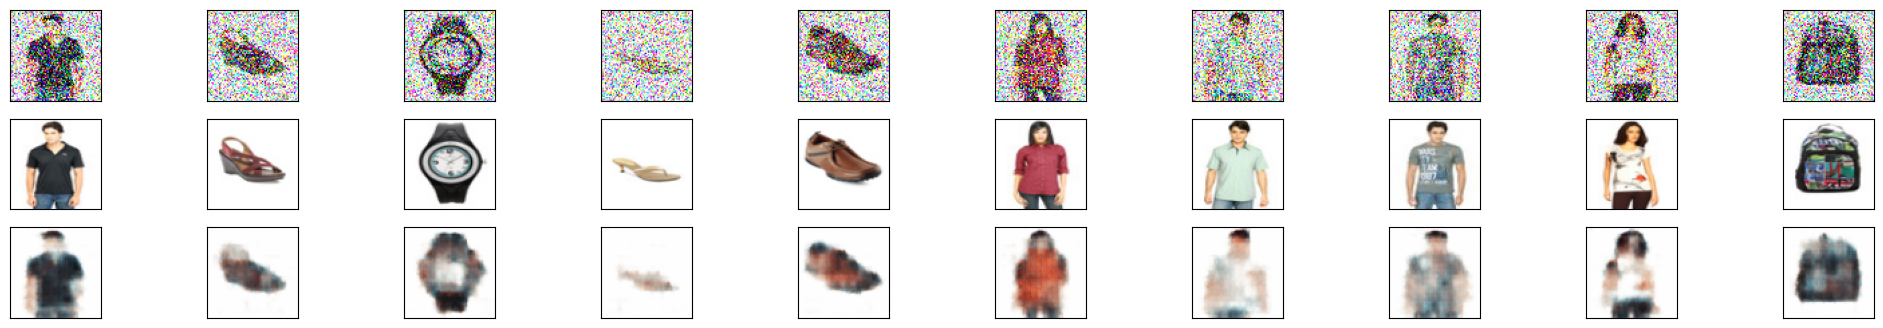

In [24]:
# 绘制前 10 张输入图像和重建图像
fig, axes = plt.subplots(nrows=3, ncols=10, sharex=True, sharey=True, figsize=(25, 4))  # 创建 2 行 10 列的子图
# 第一行显示噪声图像，第二行显示重建图像
for imgs, row in zip([noisy_images, original_images, output], axes):  # 遍历噪声图像和重建图像
    for img, ax in zip(imgs, row):  # 遍历每张图像和对应的子图
        ax.imshow(np.squeeze(img))  # 显示图像，并去除多余的维度
        ax.get_xaxis().set_visible(False)  # 隐藏 x 轴
        ax.get_yaxis().set_visible(False)  # 隐藏 y 轴
plt.show()  # 显示图像